# Project SQL: Data Discovery with the Chinook Database

Welcome to your first major hands-on data exploration project. In this assignment, you will be stepping into the role of a data analyst querying the Chinook database: a sample dataset representing a digital media store, complete with information about artists, albums, tracks, customers, and business sales.

The core objective of this project is to transition you from simply writing code to thinking like a data scientist. To do that, our journey follows a deliberate, four-fold progression:



### Phase 1. Master the Mechanics (Get Familiar with SQL)



Before you can extract deep insights, you need to speak the language. You will start by practicing the fundamental mechanics of SQL using the SQL statements below: learning how to filter data, join tables, group metrics, and aggregate numbers. Think of this as learning how to move around the data environment smoothly.  As a starting point, pick a single table and answer the "How many ...?" questions using SQL.  Then repeat the process for each table.



## Chinook data set

See the lecture on SQLite3 using the Chinook data set to set up the software, database, and tables, as well as for the links to ancillary information about the data set.


In [1]:
import sqlite3 as db
import pandas as pd
import contextlib


In [2]:
%%capture
%%bash
apt-get update
apt-get install -y sqlite3


In [3]:
!sqlite3 --version

3.37.2 2022-01-06 13:25:41 872ba256cbf61d9290b571c0e6d82a20c224ca3ad82971edc46b29818d5dalt1


In [4]:
%%bash
[ -f chinook.zip ] ||
  curl -s -O https://www.sqlitetutorial.net/wp-content/uploads/2018/03/chinook.zip
unzip -l chinook.zip


Archive:  chinook.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   884736  2015-11-29 10:53   chinook.db
---------                     -------
   884736                     1 file


In [5]:
!rm -f chinook.db


In [6]:
!unzip -u chinook.zip


Archive:  chinook.zip
  inflating: chinook.db              


In [7]:
!ls -l

total 1168
-rw-r--r-- 1 root root 884736 Nov 29  2015 chinook.db
-rw-r--r-- 1 root root 305596 Jul  9 04:34 chinook.zip
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data


Verify sqlite works.

In [9]:
query = '''
  SELECT
    name
  FROM
    sqlite_master
  WHERE
    type='table' AND
    name not like "sqlite_%"
;
'''
print(query)


  SELECT
    name
  FROM
    sqlite_master
  WHERE
    type='table' AND
    name not like "sqlite_%"
;



In [10]:
with contextlib.closing(db.connect("chinook.db")) as db_con:
  tables = pd.read_sql_query( query , db_con)

tables


,name
0,albums
1,artists
2,customers
3,employees
4,genres
5,invoices
6,invoice_items
7,media_types
8,playlists
9,playlist_track


## Use SQL queries to pull specific information

Do NOT pull all the data and then filter using DataFrame methods.  The initial purpose is to get familiar with SQL.




I'm going to focus on the `employees` table.

### Basic Queries


#### SELECT (with * and with column names)


In [14]:
query = '''
  select *
  from employees
'''
print(query)


  select *
  from employees



In [15]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2002-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2002-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2002-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com
3,4,Park,Margaret,Sales Support Agent,2.0,1947-09-19 00:00:00,2003-05-03 00:00:00,683 10 Street SW,Calgary,AB,Canada,T2P 5G3,+1 (403) 263-4423,+1 (403) 263-4289,margaret@chinookcorp.com
4,5,Johnson,Steve,Sales Support Agent,2.0,1965-03-03 00:00:00,2003-10-17 00:00:00,7727B 41 Ave,Calgary,AB,Canada,T3B 1Y7,1 (780) 836-9987,1 (780) 836-9543,steve@chinookcorp.com
5,6,Mitchell,Michael,IT Manager,1.0,1973-07-01 00:00:00,2003-10-17 00:00:00,5827 Bowness Road NW,Calgary,AB,Canada,T3B 0C5,+1 (403) 246-9887,+1 (403) 246-9899,michael@chinookcorp.com
6,7,King,Robert,IT Staff,6.0,1970-05-29 00:00:00,2004-01-02 00:00:00,590 Columbia Boulevard West,Lethbridge,AB,Canada,T1K 5N8,+1 (403) 456-9986,+1 (403) 456-8485,robert@chinookcorp.com
7,8,Callahan,Laura,IT Staff,6.0,1968-01-09 00:00:00,2004-03-04 00:00:00,923 7 ST NW,Lethbridge,AB,Canada,T1H 1Y8,+1 (403) 467-3351,+1 (403) 467-8772,laura@chinookcorp.com


In [16]:
query = '''
  select EmployeeId, LastName, FirstName
  from employees
'''
print(query)


  select EmployeeId, LastName, FirstName
  from employees



In [17]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName
0,1,Adams,Andrew
1,2,Edwards,Nancy
2,3,Peacock,Jane
3,4,Park,Margaret
4,5,Johnson,Steve
5,6,Mitchell,Michael
6,7,King,Robert
7,8,Callahan,Laura


#### WHERE


In [20]:
query = '''
  select EmployeeId, LastName, FirstName
  from employees
  where City = 'Calgary'
'''
print(query)


  select EmployeeId, LastName, FirstName
  from employees
  where City = 'Calgary'



In [21]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName
0,2,Edwards,Nancy
1,3,Peacock,Jane
2,4,Park,Margaret
3,5,Johnson,Steve
4,6,Mitchell,Michael


#### AND


In [26]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName = 'Jane'
    and City = 'Calgary'

'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName = 'Jane'
    and City = 'Calgary'




In [27]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,3,Peacock,Jane,Calgary


#### OR


In [28]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName = 'Jane'
    or City = 'Edmonton'

'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName = 'Jane'
    or City = 'Edmonton'




In [29]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,1,Adams,Andrew,Edmonton
1,3,Peacock,Jane,Calgary


#### LIKE (with % or _ wildcard)


In [30]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName like 'M%'
    or City = 'Edmonton'

'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName like 'M%'
    or City = 'Edmonton'




In [31]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,1,Adams,Andrew,Edmonton
1,4,Park,Margaret,Calgary
2,6,Mitchell,Michael,Calgary


In [32]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName like 'M%'
    or City like 'Ed__nton'

'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  where FirstName like 'M%'
    or City like 'Ed__nton'




In [33]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,1,Adams,Andrew,Edmonton
1,4,Park,Margaret,Calgary
2,6,Mitchell,Michael,Calgary


#### BETWEEN


In [34]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  where EmployeeId between 4 and 6

'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  where EmployeeId between 4 and 6




In [35]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,4,Park,Margaret,Calgary
1,5,Johnson,Steve,Calgary
2,6,Mitchell,Michael,Calgary


#### LIMIT



In [38]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  limit 3
'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  limit 3



In [39]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,1,Adams,Andrew,Edmonton
1,2,Edwards,Nancy,Calgary
2,3,Peacock,Jane,Calgary


### Sorting and Grouping


#### ORDER BY


In [40]:
query = '''
  select EmployeeId, LastName, FirstName, city
  from employees
  order by LastName, FirstName
'''
print(query)


  select EmployeeId, LastName, FirstName, city
  from employees
  order by LastName, FirstName



In [41]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,EmployeeId,LastName,FirstName,City
0,1,Adams,Andrew,Edmonton
1,8,Callahan,Laura,Lethbridge
2,2,Edwards,Nancy,Calgary
3,5,Johnson,Steve,Calgary
4,7,King,Robert,Lethbridge
5,6,Mitchell,Michael,Calgary
6,4,Park,Margaret,Calgary
7,3,Peacock,Jane,Calgary


#### DISTINCT


In [42]:
query = '''
  select distinct city
  from employees
'''
print(query)


  select distinct city
  from employees



In [43]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,City
0,Edmonton
1,Calgary
2,Lethbridge


#### GROUP BY



In [72]:
query = '''
  select city
  from employees
  group by city
'''
print(query)


  select city
  from employees
  group by city



In [73]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,City
0,Calgary
1,Edmonton
2,Lethbridge


### Aggregates


#### MAX


In [60]:
query = '''
  select max(HireDate) as 'latest_employee'
  from employees
'''
print(query)


  select max(HireDate) as 'latest_employee'
  from employees



In [61]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,latest_employee
0,2004-03-04 00:00:00


#### MIN


In [58]:
query = '''
  select min(HireDate) as 'first_employee'
  from employees
'''
print(query)


  select min(HireDate) as 'first_employee'
  from employees



In [59]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,first_employee
0,2002-04-01 00:00:00


#### SUM


In [68]:
query = '''
  select sum(employeeid) as 'bogus_sum'
  from employees
'''
print(query)


  select sum(employeeid) as 'bogus_sum'
  from employees



In [69]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,bogus_sum
0,36


#### AVG


In [70]:
query = '''
  select avg(employeeid) as 'bogus_mean'
  from employees
'''
print(query)


  select avg(employeeid) as 'bogus_mean'
  from employees



In [71]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,bogus_mean
0,4.5


#### COUNT



In [74]:
query = '''
  select city, count(1) as 'count'
  from employees
  group by city
  order by count desc
'''
print(query)


  select city, count(1) as 'count'
  from employees
  group by city
  order by count desc



In [75]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,City,count
0,Calgary,5
1,Lethbridge,2
2,Edmonton,1


## Make some plots

Make some cool plots to go with your data. Write SQL queries to get ONLY the information you need for each plot. (Don't pull ALL the data and then just plot a few columns.)



In [76]:
query = '''
  select city, count(1) as 'count'
  from employees
  group by city
  order by count desc
'''
print(query)


  select city, count(1) as 'count'
  from employees
  group by city
  order by count desc



In [77]:
# Connect to a sqlite database, load a result set into a data frame, and close the connection
with contextlib.closing(db.connect("chinook.db")) as db_con:
  df = pd.read_sql_query( query , db_con)

df

,City,count
0,Calgary,5
1,Lethbridge,2
2,Edmonton,1


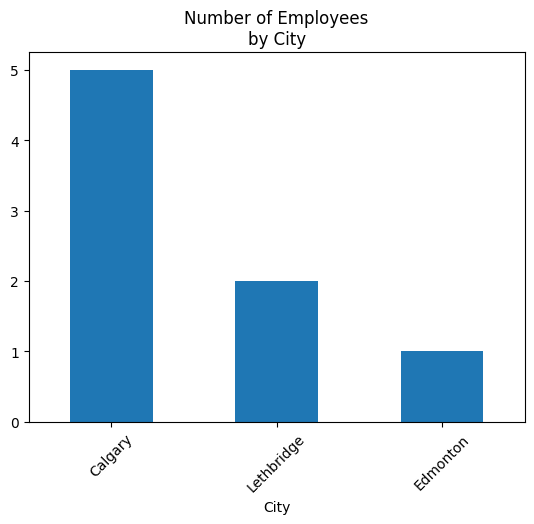

In [83]:
df.set_index("City").plot(
    kind='bar',
    rot=45,
    legend=False,
    title="Number of Employees\nby City",
) ;


## EXTRA CREDIT:
* Use a CTE
* Use a query that joins two or more tables.
* Make a model to see if you can predict something ( e.g. GNB classifier, linear regression )
* Come up with something else cool to do with your data


### Using DuckDB



In [116]:
import duckdb


In [117]:
# Connect to an in-memory DuckDB instance
conn = duckdb.connect()


In [118]:
# Load the SQLite extension and attach your SQLite database file
conn.execute("LOAD sqlite;")
conn.execute("ATTACH 'chinook.db' AS chinook (TYPE SQLITE);")


#### regex named groups

In [119]:
# Query the SQLite table using DuckDB's regex engine and unpack the struct
query = r'''
    SELECT
        employeeid,
        phone,
        regexp_extract(
            phone,
            '\((\d{3})\)\s*(\d{3})-(\d{4})',
            ['area_code', 'exchange', 'line']
        ) as phone_parts
    FROM chinook.employees;
'''
print(query)



    SELECT 
        employeeid,
        phone,
        regexp_extract(
            phone, 
            '\((\d{3})\)\s*(\d{3})-(\d{4})', 
            ['area_code', 'exchange', 'line']
        ) as phone_parts
    FROM chinook.employees;



#### CTE, regex expanded named groups


In [ ]:
# Query the SQLite table using DuckDB's regex engine and unpack the struct
query = r'''
WITH extracted_data AS (
  SELECT
    employeeid,
    phone,
    regexp_extract(
      phone,
      '\((\d{3})\)\s*(\d{3})-(\d{4})',
      ['area_code', 'exchange', 'line']
    ) as phone_parts
  FROM chinook.employees
)

SELECT
  * EXCLUDE (phone_parts),
  phone_parts.*
FROM extracted_data;
'''
print(query)



WITH extracted_data AS (
  SELECT
    employeeid,
    phone,
    regexp_extract(
      phone,
      '\((\d{3})\)\s*(\d{3})-(\d{4})',
      ['area_code', 'exchange', 'line']
    ) as phone_parts
  FROM chinook.employees
)

SELECT 
  * EXCLUDE (phone_parts),
  phone_parts.*
FROM extracted_data;



In [ ]:
# Fetch the results into a Pandas DataFrame
df = conn.query(query).to_df()
df

,EmployeeId,Phone,area_code,exchange,line
0,1,+1 (780) 428-9482,780,428,9482
1,2,+1 (403) 262-3443,403,262,3443
2,3,+1 (403) 262-3443,403,262,3443
3,4,+1 (403) 263-4423,403,263,4423
4,5,1 (780) 836-9987,780,836,9987
5,6,+1 (403) 246-9887,403,246,9887
6,7,+1 (403) 456-9986,403,456,9986
7,8,+1 (403) 467-3351,403,467,3351


#### CTE, regex expanded named groups, country code

In [ ]:
# Query the SQLite table using DuckDB's regex engine and unpack the struct
query = r'''
WITH extracted_data AS (
  SELECT
    employeeid,
    phone,
    regexp_extract(
      phone,
      '(\+\d{1,2})\s*\((\d{3})\)\s*(\d{3})-(\d{4})',
      ['country_code','area_code', 'exchange', 'line']
    ) as phone_parts
  FROM chinook.employees
)

SELECT
  * EXCLUDE (phone_parts),
  phone_parts.*
FROM extracted_data;
'''
print(query)



WITH extracted_data AS (
  SELECT
    employeeid,
    phone,
    regexp_extract(
      phone,
      '(\+\d{1,2})\s*\((\d{3})\)\s*(\d{3})-(\d{4})',
      ['country_code','area_code', 'exchange', 'line']
    ) as phone_parts
  FROM chinook.employees
)

SELECT 
  * EXCLUDE (phone_parts),
  phone_parts.*
FROM extracted_data;



In [ ]:
# Fetch the results into a Pandas DataFrame
df = conn.query(query).to_df()
df

,EmployeeId,Phone,country_code,area_code,exchange,line
0,1,+1 (780) 428-9482,+1,780,428,9482
1,2,+1 (403) 262-3443,+1,403,262,3443
2,3,+1 (403) 262-3443,+1,403,262,3443
3,4,+1 (403) 263-4423,+1,403,263,4423
4,5,1 (780) 836-9987,,,,
5,6,+1 (403) 246-9887,+1,403,246,9887
6,7,+1 (403) 456-9986,+1,403,456,9986
7,8,+1 (403) 467-3351,+1,403,467,3351
